<a href="https://colab.research.google.com/github/Aartizikre150/YNCN-DS-Challenge-2026-2027/blob/main/Aarti_Zikre_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Data

In [96]:
# Import the pandas library for data manipulation
import pandas as pd

# Load the JSON data from the specified path into a pandas DataFrame
df = pd.read_json('/content/DS_challenge_dataset.json')

In [97]:
# Import pandas for data manipulation and json_normalize for flattening nested JSON
import pandas as pd
from pandas import json_normalize

# Flatten the 'records' column of the DataFrame into a new DataFrame called df_flat
df_flat = json_normalize(df['records'])

In [98]:
# Display the first 5 rows of the flattened DataFrame to inspect its structure and content
display(df_flat.head())

,event_id,event_name,event_date,event_type,location,registrations,attendance,new_attendees,repeat_attendees,no_show_count,status,host_team,notes,speaker_count,promo_code_used,notes.comment
0,YNCN-1093,Women in Leadership Panel,2024-03-26,Talk,Waterfront,75,41,33,8,34,completed,Community,Good Q&A engagement,NaN,NaN,NaN
1,YNCN-1063,Budgeting Basics,2024-06-14,Social,Suburb,89,51,31,20,38,cancelled,Programs,Weather may have affected attendance,NaN,NaN,NaN
2,YNCN-1090,Women in Leadership Panel,2024-09-20,Social,Community Center,65,51,31,20,14,postponed,Community,,NaN,NaN,NaN
3,YNCN-1046,Year-End Celebration,2024-08-30,Panel,Waterfront,92,51,17,34,41,completed,Partnerships,Good Q&A engagement,NaN,NaN,NaN
4,YNCN-1069,Mentorship Match Night,2025-04-19,Forum,Community Center,118,82,53,29,36,cancelled,Partnerships,Strong turnout after partner promotion,NaN,NaN,NaN


### Transform Data considering answering two questions:

*   Which 5 events had the highest attendance?
*   How many new attendees were there by event type?





In [99]:
# Print the shape (number of rows and columns) of the df_flat DataFrame
print(df_flat.shape)

(97, 16)


In [100]:
# Remove specified columns from the df_flat DataFrame as they are not needed for analysis
df_flat = df_flat.drop(columns=['speaker_count', 'promo_code_used', 'notes.comment'])
# Display the first 5 rows of the DataFrame to confirm the columns have been dropped
display(df_flat.head())

,event_id,event_name,event_date,event_type,location,registrations,attendance,new_attendees,repeat_attendees,no_show_count,status,host_team,notes
0,YNCN-1093,Women in Leadership Panel,2024-03-26,Talk,Waterfront,75,41,33,8,34,completed,Community,Good Q&A engagement
1,YNCN-1063,Budgeting Basics,2024-06-14,Social,Suburb,89,51,31,20,38,cancelled,Programs,Weather may have affected attendance
2,YNCN-1090,Women in Leadership Panel,2024-09-20,Social,Community Center,65,51,31,20,14,postponed,Community,
3,YNCN-1046,Year-End Celebration,2024-08-30,Panel,Waterfront,92,51,17,34,41,completed,Partnerships,Good Q&A engagement
4,YNCN-1069,Mentorship Match Night,2025-04-19,Forum,Community Center,118,82,53,29,36,cancelled,Partnerships,Strong turnout after partner promotion


In [101]:
# Display a concise summary of the DataFrame, including data types and non-null values for each column
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   event_id          97 non-null     object
 1   event_name        96 non-null     object
 2   event_date        97 non-null     object
 3   event_type        97 non-null     object
 4   location          96 non-null     object
 5   registrations     96 non-null     object
 6   attendance        96 non-null     object
 7   new_attendees     97 non-null     int64 
 8   repeat_attendees  97 non-null     int64 
 9   no_show_count     97 non-null     object
 10  status            96 non-null     object
 11  host_team         97 non-null     object
 12  notes             86 non-null     object
dtypes: int64(2), object(11)
memory usage: 10.0+ KB


In [102]:
# Convert the 'registrations' column to numeric, coercing errors to NaN, filling NaN with 0, then converting to integer
df_flat['registrations'] = pd.to_numeric(df_flat['registrations'], errors='coerce').fillna(0).astype(int)
# Convert the 'attendance' column to numeric, coercing errors to NaN, filling NaN with 0, then converting to integer
df_flat['attendance'] = pd.to_numeric(df_flat['attendance'], errors='coerce').fillna(0).astype(int)
# Display updated DataFrame information to confirm the data type changes
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   event_id          97 non-null     object
 1   event_name        96 non-null     object
 2   event_date        97 non-null     object
 3   event_type        97 non-null     object
 4   location          96 non-null     object
 5   registrations     97 non-null     int64 
 6   attendance        97 non-null     int64 
 7   new_attendees     97 non-null     int64 
 8   repeat_attendees  97 non-null     int64 
 9   no_show_count     97 non-null     object
 10  status            96 non-null     object
 11  host_team         97 non-null     object
 12  notes             86 non-null     object
dtypes: int64(4), object(9)
memory usage: 10.0+ KB


In [103]:
# Calculate and print the total number of duplicate rows in the DataFrame
print(f"Number of duplicate rows: {df_flat.duplicated().sum()}")

Number of duplicate rows: 3


In [104]:
# Filter the DataFrame to show all duplicate rows, keeping both original and duplicated entries
duplicate_rows = df_flat[df_flat.duplicated(keep=False)]
# Display the duplicate rows, sorted by all columns for easier inspection
display(duplicate_rows.sort_values(by=list(df_flat.columns)))

,event_id,event_name,event_date,event_type,location,registrations,attendance,new_attendees,repeat_attendees,no_show_count,status,host_team,notes
54,YNCN-1006,Founder Fireside,2025-10-04,Networking,Library Hall,127,101,95,6,26,Completed,Partnerships,Strong turnout after partner promotion
71,YNCN-1006,Founder Fireside,2025-10-04,Networking,Library Hall,127,101,95,6,26,Completed,Partnerships,Strong turnout after partner promotion
26,YNCN-1013,Spring Mixer,2025-06-14,Workshop,Library Hall,161,94,11,83,67,Completed,Ops,
75,YNCN-1013,Spring Mixer,2025-06-14,Workshop,Library Hall,161,94,11,83,67,Completed,Ops,
21,YNCN-1028,Career Panel,2025-05-21,Workshop,Suburb,158,101,56,45,57,completed,Ops,Good Q&A engagement
50,YNCN-1028,Career Panel,2025-05-21,Workshop,Suburb,158,101,56,45,57,completed,Ops,Good Q&A engagement


In [105]:
# Remove duplicate rows from the DataFrame, keeping only the first occurrence
df_flat.drop_duplicates(inplace=True)

In [106]:
# Display a concise summary of the DataFrame after removing duplicates, including data types and non-null values
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 0 to 96
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   event_id          94 non-null     object
 1   event_name        93 non-null     object
 2   event_date        94 non-null     object
 3   event_type        94 non-null     object
 4   location          93 non-null     object
 5   registrations     94 non-null     int64 
 6   attendance        94 non-null     int64 
 7   new_attendees     94 non-null     int64 
 8   repeat_attendees  94 non-null     int64 
 9   no_show_count     94 non-null     object
 10  status            93 non-null     object
 11  host_team         94 non-null     object
 12  notes             83 non-null     object
dtypes: int64(4), object(9)
memory usage: 10.3+ KB


In [107]:
# Iterate through each column in the DataFrame
for col in df_flat.columns:
    # Print all unique values in the current column
    print(f"Unique values in column '{col}': {df_flat[col].unique()}")
    # Print the count of unique values in the current column
    print(f"Number of unique values in column '{col}': {df_flat[col].nunique()}\n")

Unique values in column 'event_id': ['YNCN-1093' 'YNCN-1063' 'YNCN-1090' 'YNCN-1046' 'YNCN-1069' 'YNCN-1024'
 'YNCN-1079' 'YNCN-1075' 'YNCN-1047' 'YNCN-1005' 'YNCN-1055' 'YNCN-1051'
 'YNCN-1080' 'YNCN-1089' 'YNCN-1074' 'YNCN-1082' 'YNCN-1053' 'YNCN-1036'
 'YNCN-1071' 'YNCN-1002' 'YNCN-1014' 'YNCN-1028' 'YNCN-1054' 'YNCN-1087'
 'YNCN-1001' 'YNCN-1017' 'YNCN-1013' 'YNCN-1025' 'YNCN-1068' 'YNCN-1050'
 'YNCN-1009' 'YNCN-1043' 'YNCN-1048' 'YNCN-1066' 'YNCN-1062' 'YNCN-1026'
 'YNCN-1091' 'YNCN-1081' 'YNCN-1045' 'YNCN-1044' 'YNCN-1085' 'YNCN-1007'
 'YNCN-1021' 'YNCN-1088' 'YNCN-1027' 'YNCN-1023' 'YNCN-1058' 'YNCN-1072'
 'YNCN-1032' 'YNCN-1041' 'YNCN-1038' 'YNCN-1059' 'YNCN-1018' 'YNCN-1006'
 'YNCN-1076' 'YNCN-1034' 'YNCN-1031' 'YNCN-1067' 'YNCN-1061' 'YNCN-1049'
 'YNCN-1086' 'YNCN-1084' 'YNCN-1078' 'YNCN-1003' 'YNCN-1030' 'YNCN-1012'
 'YNCN-1004' 'YNCN-1033' 'YNCN-1042' 'YNCN-1056' 'YNCN-1011' 'YNCN-1094'
 'YNCN-1064' 'YNCN-1065' 'YNCN-1092' 'YNCN-1052' 'YNCN-1039' 'YNCN-1060'
 'YNCN-1016' 'Y

In [108]:
# Standardize 'Work Shop' to 'Workshop' in the 'event_type' column for consistency
df_flat['event_type'] = df_flat['event_type'].replace('Work Shop', 'Workshop')
# Print unique values in 'event_type' to confirm the change
print(f"Unique values in column 'event_type' after cleaning: {df_flat['event_type'].unique()}\n")

Unique values in column 'event_type' after cleaning: ['Talk' 'Social' 'Panel' 'Forum' 'Workshop' 'Networking' 'networking'
 'Roundtable']



In [109]:
# Replace various representations of missing location data ('', 'null', None) with 'NA'
df_flat['location'] = df_flat['location'].replace({'': 'NA', 'null': 'NA', None: 'NA'})
# Print unique values in 'location' to confirm the changes
print(f"Unique values in column 'location' after cleaning: {df_flat['location'].unique()}\n")

Unique values in column 'location' after cleaning: ['Waterfront' 'Suburb' 'Community Center' 'NA' 'Online' 'Downtown'
 'Library Hall' 'Midtown' ' downtown ']



In [110]:
# Standardize various representations of 'completed' status to 'completed'
df_flat['status'] = df_flat['status'].replace(['Completed', 'Complete', 'COMPLETE', 'completed '], 'completed')
# Print unique values in 'status' to confirm the changes
print(f"Unique values in column 'status' after cleaning: {df_flat['status'].unique()}\n")

Unique values in column 'status' after cleaning: ['completed' 'cancelled' 'postponed' nan]



In [111]:
import numpy as np

# Identify object columns to process
object_cols = df_flat.select_dtypes(include='object').columns

for col in object_cols:
    # Replace empty strings and strings with only whitespace
    df_flat[col] = df_flat[col].replace(r'^\s*$', np.nan, regex=True)
    # Replace 'NA', 'none', 'null' (case-insensitive) and Python None with np.nan
    df_flat[col] = df_flat[col].replace(['NA', 'Na', 'na', 'none', 'None', 'null', 'Null', None], np.nan, regex=False)

# Convert 'no_show_count' to numeric, coercing errors to NaN
df_flat['no_show_count'] = pd.to_numeric(df_flat['no_show_count'], errors='coerce')

# Display updated info to confirm changes
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 0 to 96
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   event_id          94 non-null     object
 1   event_name        92 non-null     object
 2   event_date        93 non-null     object
 3   event_type        94 non-null     object
 4   location          91 non-null     object
 5   registrations     94 non-null     int64 
 6   attendance        94 non-null     int64 
 7   new_attendees     94 non-null     int64 
 8   repeat_attendees  94 non-null     int64 
 9   no_show_count     94 non-null     int64 
 10  status            93 non-null     object
 11  host_team         94 non-null     object
 12  notes             65 non-null     object
dtypes: int64(5), object(8)
memory usage: 10.3+ KB


In [112]:
# Filter the DataFrame to select only rows where 'event_id' is 'YNCN-1009'
filtered_df = df_flat[df_flat['event_id'] == 'YNCN-1009']
# Display the filtered DataFrame
display(filtered_df)

,event_id,event_name,event_date,event_type,location,registrations,attendance,new_attendees,repeat_attendees,no_show_count,status,host_team,notes
30,YNCN-1009,Design Thinking Lab,2025-04-27,Workshop,Library Hall,132,0,86,1,45,completed,Programs,Weather may have affected attendance


In [113]:
# Remove rows where 'attendance' is 0 AND 'status' is 'completed'
df_flat = df_flat[~((df_flat['attendance'] == 0) & (df_flat['status'] == 'completed'))]
# Print the new shape of the DataFrame after removing these rows
print(f"New shape of df_flat: {df_flat.shape}")

New shape of df_flat: (93, 13)


In [114]:
# Remove rows where the 'attendance' column has a negative value
df_flat = df_flat[df_flat['attendance'] >= 0]
# Print the new shape of the DataFrame after removing these rows
print(f"New shape of df_flat after removing rows with negative attendance: {df_flat.shape}")

New shape of df_flat after removing rows with negative attendance: (92, 13)


In [115]:
# Store the initial number of rows to calculate how many were removed
initial_rows = df_flat.shape[0]
# Remove rows where 'event_name' is a missing value (NaN)
df_flat.dropna(subset=['event_name'], inplace=True)
# Print the number of rows removed and the new DataFrame shape
print(f"Removed {initial_rows - df_flat.shape[0]} rows with empty event_name.")
print(f"New shape of df_flat: {df_flat.shape}")

Removed 2 rows with empty event_name.
New shape of df_flat: (90, 13)


### ANSWER

#### Which 5 events had the highest attendance?


In [116]:
# Filter for completed events
completed_events = df_flat[df_flat['status'] == 'completed']

# Group by event_name and sum attendance, then sort to find the top 5
top_5_events_attendance = completed_events.groupby('event_name')['attendance'].sum().nlargest(5).reset_index()

display(top_5_events_attendance)

,event_name,attendance
0,Holiday Social,790
1,Design Thinking Lab,681
2,Civic Engagement Forum,437
3,Health & Wellness Session,383
4,Founder Fireside,340


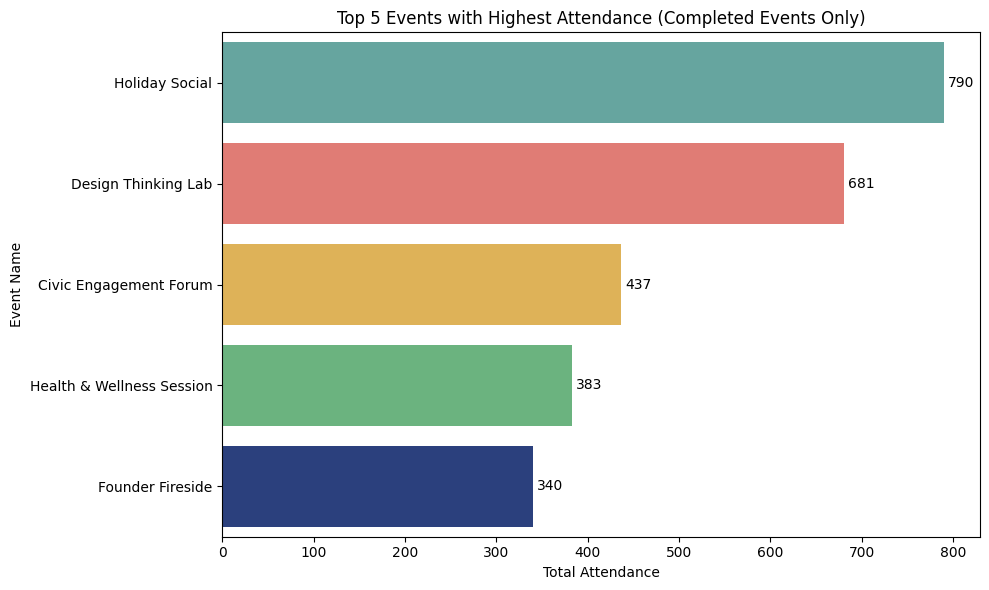

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your custom color palette
custom_palette = [
    "#5BAFA8",  # Teal
    "#F26C63",  # Coral
    "#F4B942",  # Mustard
    "#5FBF7A",  # Green
    "#1E3A8A"   # Deep Navy
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='attendance',
    y='event_name',
    data=top_5_events_attendance,
    palette=custom_palette,
    hue='event_name', # Assign event_name to hue as suggested by the warning
    legend=False      # Set legend to False to avoid a redundant legend
)

plt.xlabel('Total Attendance')
plt.ylabel('Event Name')
plt.title('Top 5 Events with Highest Attendance (Completed Events Only)')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

#### How many new attendees were there by event type?


In [129]:
# Filter for completed events
completed_events = df_flat[df_flat['status'] == 'completed']

# Group by 'event_type' and sum 'new_attendees'
new_attendees_by_event_type = completed_events.groupby('event_type')['new_attendees'].sum().reset_index()

# Display the results, sorted by new attendees in descending order
display(new_attendees_by_event_type.sort_values(by='new_attendees', ascending=False))

,event_type,new_attendees
3,Roundtable,744
2,Panel,729
1,Networking,599
0,Forum,449
4,Social,380
6,Workshop,310
5,Talk,250
7,networking,7


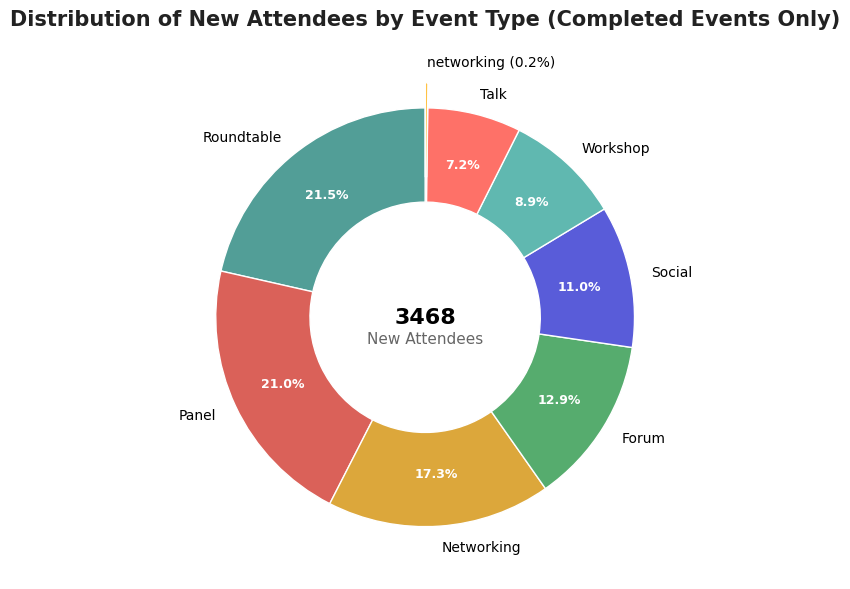

In [141]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# Sort data for better visualization
# -----------------------------
data = new_attendees_by_event_type.sort_values(
    by='new_attendees',
    ascending=False
).copy()

# -----------------------------
# Calculate total and percentage for each slice
# -----------------------------
total = data['new_attendees'].sum()
data['percentage'] = data['new_attendees'] / total * 100

# -----------------------------
# Identify the smallest slice to explode it in the donut chart
# -----------------------------
min_index = data['new_attendees'].idxmin()

explode = [0] * len(data)
explode[min_index] = 0.12  # Explode the smallest slice slightly

# -----------------------------
# Modify labels for the chart, highlighting the smallest slice's percentage
# -----------------------------
labels = []

for i, row in data.iterrows():
    if i == min_index:
        labels.append(f"{row['event_type']} ({row['percentage']:.1f}%)")
    else:
        labels.append(row['event_type'])

# -----------------------------
# Define a custom color palette for the chart
# -----------------------------
base_colors = ["#5BAFA8", "#F26C63", "#F4B942", "#5FBF7A", "#6366F1"]

def generate_palette(base_colors, n):
    colors = []
    for i in range(n):
        base = mcolors.to_rgb(base_colors[i % len(base_colors)])
        factor = 0.9 + (i // len(base_colors)) * 0.15
        colors.append(tuple(min(1, c * factor) for c in base))
    return colors[:n]

colors = generate_palette(base_colors, len(data))

# -----------------------------
# Create the donut chart
# -----------------------------
plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    data['new_attendees'],
    labels=labels,  # Use custom labels with percentage for the smallest slice
    colors=colors,
    explode=explode,
    startangle=90,
    autopct=lambda p: f'{p:.1f}%' if p >= 2 else '', # Display percentage only for slices >= 2%
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white') # Define inner hole for donut effect
)

# Apply style to the text labels
for text in texts:
    text.set_fontsize(10)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("white")
    autotext.set_weight("bold")

# Add total new attendees in the center of the donut chart
plt.text(0, 0, f"{int(total)}", ha='center', va='center',
         fontsize=16, fontweight='bold')

# Add a descriptive label below the total
plt.text(
    0, -0.10,
    "New Attendees",
    ha='center',
    va='center',
    fontsize=11,
    color="#666666"
)

# Set the title of the chart
plt.title(
    "Distribution of New Attendees by Event Type (Completed Events Only)",
    fontsize=15,
    fontweight='bold',
    color="#222222",
    pad=22
)


plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#### What data quality issues exist in the dataset, and how would you handle them before analyzing attendance? (Considering that we need to answer above two questions only)


*   Flattened nested JSON data into a structured dataframe using json_normalize.
*   Dropped irrelevant columns such as speaker_count, promo_code_used, and notes.comment.
*   Converted key numeric columns (registrations, attendance, no_show_count) to numeric types using pd.to_numeric() with error handling.
*   Handled invalid numeric values by coercing errors and replacing them with 0 where appropriate.
*   Identified and removed duplicate records using drop_duplicates().
*   Inspected unique values across columns to detect inconsistencies and data quality issues.
*   Standardized categorical values:
*     Corrected Work Shop to Workshop in event_type.
*     Unified multiple variations of status (e.g., Completed, COMPLETE, completed ) into completed.
*   Cleaned missing and placeholder values by converting blanks, whitespace, null, None, and similar entries into proper NaN.

*   Standardized inconsistent location values by replacing empty and null-like entries with a consistent placeholder (NA).
*   Removed logically invalid records:
*     Rows where attendance = 0 for completed events.
*     Rows with negative attendance values.    
*   Dropped rows with missing event_name to ensure meaningful reporting for top events analysis.
